## KMeans

(3000, 2) (3000,)


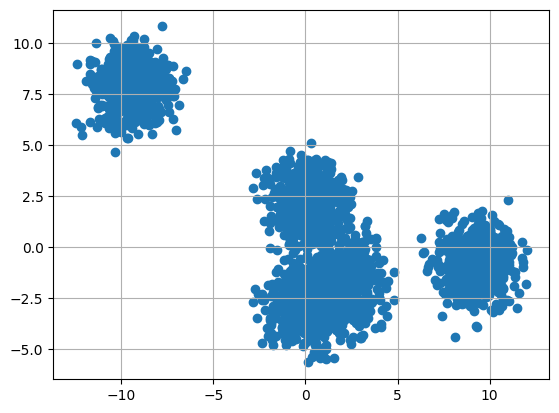

In [4]:
from sklearn.datasets import make_blobs

k = 5
X, y = make_blobs(n_samples=3000, centers=k, center_box=(-10.0, 10.0))
print(X.shape, y.shape)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], marker="o")
plt.grid(True)
plt.show()

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=k, init="random", n_init=20, random_state=42) # default
y_pred = kmeans.fit_predict(X)
print(kmeans.labels_ is y_pred)
print(kmeans.cluster_centers_)
print(kmeans.inertia_, kmeans.score(X))

True
[[ 0.03652899 -2.95630057]
 [-9.46021003  7.81207182]
 [ 0.18484694  2.16116691]
 [ 9.21631493 -0.79762781]
 [ 2.1597852  -1.58458087]]
5612.302103239049 -5612.30210323905


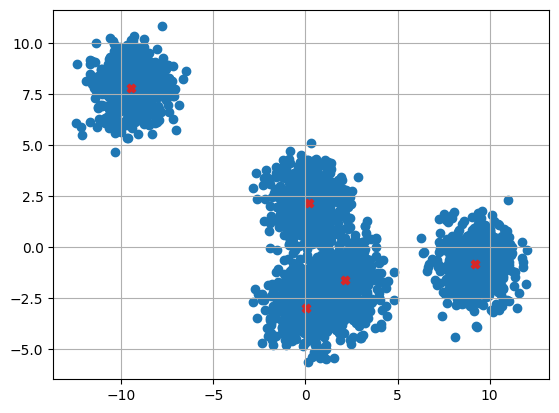

In [6]:
ax.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker="X", color="C3")
fig

In [7]:
import numpy as np
X_new = np.array([[0, 2], [3, 2], [-7, 3], [-3, 15]])

print(kmeans.predict(X_new)) # hard clustering
print(kmeans.transform(X_new).round(2)) # soft clustering, distancia a cada centroide

[2 2 1 1]
[[ 4.96 11.1   0.25  9.63  4.18]
 [ 5.77 13.75  2.82  6.82  3.68]
 [ 9.22  5.4   7.23 16.66 10.24]
 [18.21  9.66 13.23 19.97 17.37]]


In [8]:
kmeans_optim = KMeans(n_clusters=k, init="k-means++", random_state=42) # default n_init=1
kmeans_optim.fit(X)

print(kmeans_optim.cluster_centers_)
print(kmeans_optim.inertia_)

[[ 0.18840111  2.15907052]
 [-9.46021003  7.81207182]
 [ 2.1440327  -1.59461078]
 [ 9.21631493 -0.79762781]
 [ 0.02375119 -2.96895203]]
5612.694079068078


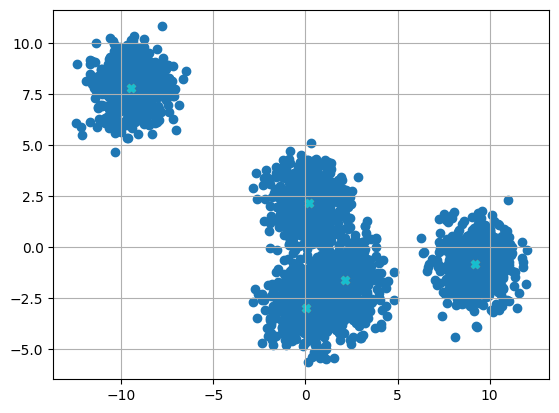

In [9]:
ax.scatter(kmeans_optim.cluster_centers_[:,0], kmeans_optim.cluster_centers_[:,1], marker="X", color="C9")
fig

In [10]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np

n_batches = 200
mb_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42)
for X_batch in np.array_split(X, n_batches):
    mb_kmeans.partial_fit(X_batch)

print(mb_kmeans.cluster_centers_)
print(mb_kmeans.inertia_)

[[ -8.51865859   8.14811862]
 [  0.38907775   1.86617151]
 [  9.21631493  -0.79762781]
 [-10.09228216   7.58648052]
 [  1.09743298  -2.36921173]]
31.018145446225144


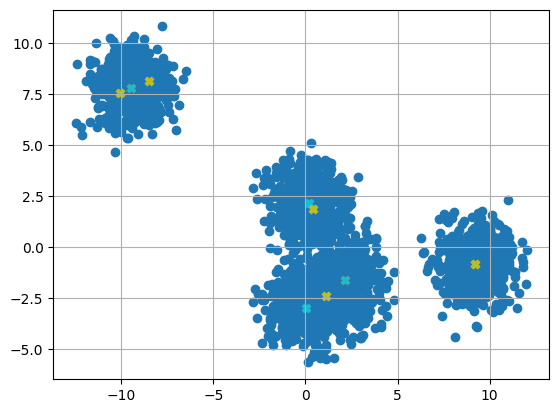

In [11]:
ax.scatter(mb_kmeans.cluster_centers_[:,0], mb_kmeans.cluster_centers_[:,1], marker="X", color="C8")
fig

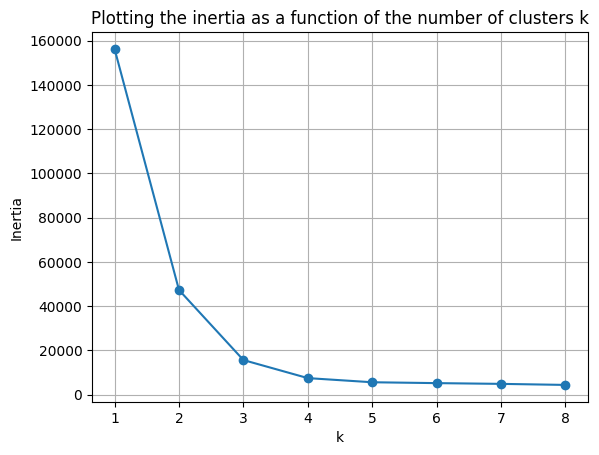

In [12]:
num_clusters = 8
inertia = []
for k in range(1,num_clusters+1):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    
fig2, ax2 = plt.subplots()
ax2.plot([k for k in range(1,num_clusters+1)], inertia, marker="o")
ax2.set_xlabel("k")
ax2.set_ylabel("Inertia")
ax2.set_title("Plotting the inertia as a function of the number of clusters k")
plt.grid(True)
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
print(silhouette_score(X, kmeans.labels_))

0.6549498228899486


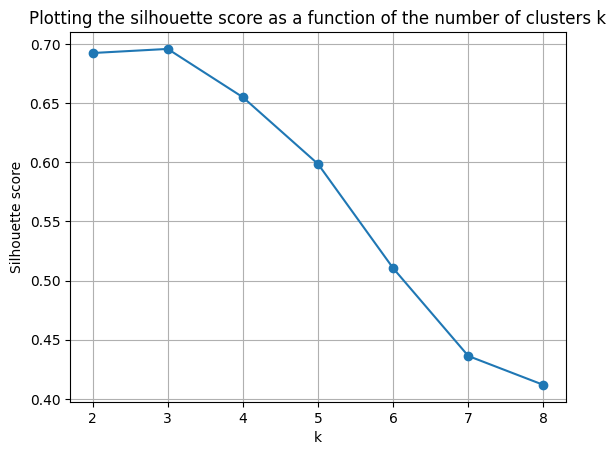

In [14]:
from sklearn.metrics import silhouette_score

num_clusters = 8
scores = []
for k in range(2,num_clusters+1): # silhouette_score es apartir de 2 clustes
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    scores.append(silhouette_score(X, kmeans.labels_))

fig3, ax3 = plt.subplots()
ax3.plot([k for k in range(2,num_clusters+1)], scores, marker="o")
ax3.set_xlabel("k")
ax3.set_ylabel("Silhouette score")
ax3.set_title("Plotting the silhouette score as a function of the number of clusters k")
plt.grid(True)
plt.show()

## Density Based Spatial Clustering Application Noise

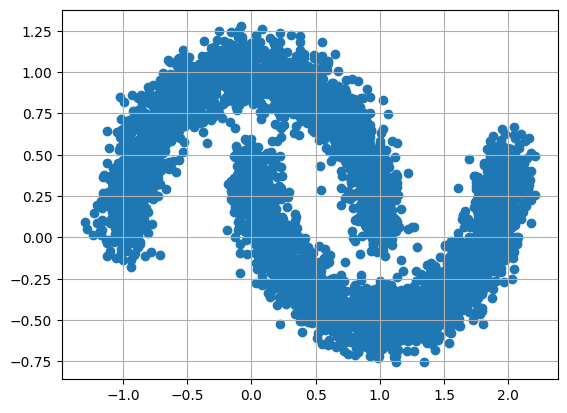

[ 0  1  1 ... -1  1  0]
6
[   0    1    2 ... 4996 4998 4999]


In [15]:
from sklearn.cluster import DBSCAN 
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=5000, noise=0.1, random_state=42)

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots() 
ax.scatter(X_moon[:,0], X_moon[:,1], marker="o", color="C0")
plt.grid(True)
plt.show()

dbscan = DBSCAN(eps=0.045, min_samples=15)
dbscan.fit(X_moon)

# DBSACAN tiene metodo fit_predict() pero no predict() ni predict_proba()

labels = dbscan.labels_
print(labels) # las anomalias tiene etiqueta -1
print(len(np.unique(labels)))
print(dbscan.core_sample_indices_) # the indices of the core instances

[[-0.1196884   1.03684845]
 [ 0.03370055  0.2493631 ]
 [ 0.03864294  0.33033539]
 ...
 [ 0.85986767  0.60326185]
 [ 1.14571078 -0.44817941]
 [ 0.39745697  0.92398746]]


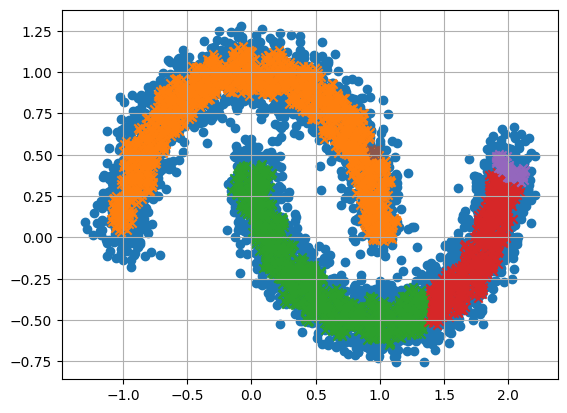

In [16]:
print(dbscan.components_) # the core instances themselves

for i in np.unique(labels)[1:]:
    X_i = X_moon[labels==i]
    ax.scatter(X_i[:,0], X_i[:,1], marker="x", color="C%s" %(i+1))
fig

## Gaussian Mixture Models

In [17]:
from sklearn.mixture import GaussianMixture

k = 5 # necesitas saberlo de antemano
gmm = GaussianMixture(n_components=k, n_init=10, random_state=42)
gmm.fit(X)

print(gmm.weights_)
print(gmm.means_)
print(gmm.covariances_)

[0.19968488 0.2        0.1974981  0.20000138 0.20281564]
[[ 0.18879897  2.16414438]
 [-9.46021003  7.81207182]
 [ 0.15787055 -2.85075496]
 [ 9.2162793  -0.79763582]
 [ 2.1106349  -1.6023674 ]]
[[[ 0.97223654 -0.0413296 ]
  [-0.0413296   0.99775601]]

 [[ 1.05089001  0.04612494]
  [ 0.04612494  0.97991558]]

 [[ 1.02984878 -0.00935404]
  [-0.00935404  0.96665622]]

 [[ 1.01820072 -0.00385559]
  [-0.00385559  1.03070385]]

 [[ 0.88229665 -0.06344124]
  [-0.06344124  1.06225701]]]


In [18]:
print(gmm.converged_)
print(gmm.n_iter_)

True
4


In [19]:
print(gmm.predict(X_new)) # hard assignment clustering
print(gmm.predict_proba(X_new)) # soft assignment clustering

[0 0 1 1]
[[9.99687047e-01 7.91156942e-28 5.19088809e-06 1.88232886e-20
  3.07762392e-04]
 [9.37214505e-01 4.62339025e-40 4.79534351e-06 7.21474096e-09
  6.27806921e-02]
 [1.08273291e-05 9.99989173e-01 2.01356636e-12 3.96684022e-53
  1.06084783e-17]
 [6.08516355e-19 1.00000000e+00 5.63547479e-55 1.27662139e-65
  4.96750408e-42]]


In [20]:
X_new, y_new = gmm.sample(3) # ES UN MODELO GENERATIVO !!!

print(X_new, y_new)

[[ -8.56443795   8.60087196]
 [-10.15630464   8.57134097]
 [  0.66764371  -3.44599677]] [1 1 2]
